In [1]:
import numpy as np

# Load the file directly from disk
print("📥 Loading preprocessed data...")
data = np.load('/kaggle/input/datasets/alieldinalaa/machine-fault-recognition-preprocessed/cleaned_melspecs_checkpoint.npz')

X_scaled = data['X']
y_full = data['y']

print(f"✅ Loaded! X Shape: {X_scaled.shape}")
# -> Now proceed straight to your VGG CNN cell!

📥 Loading preprocessed data...
✅ Loaded! X Shape: (56236, 128, 128, 1)


## CNN Header (VGG Arch)

In [2]:
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras import layers, models, callbacks
import tensorflow as tf

print("🏗️ Building Upgraded VGG-Style CNN (with BatchNorm)...")

inputs = layers.Input(shape=(128, 128, 1))

# Block 1
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x) # Output: 64x64

# Block 2
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x) # Output: 32x32

# Block 3
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x) # Output: 16x16

# Block 4 (NEW: Deeper semantic extraction)
x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x) # Output: 8x8

# --- THE EXTRACTION BOTTLENECK ---
# Now produces a 256-dimension vector instead of 128
gap_layer = layers.GlobalAveragePooling2D(name='semantic_embeddings')(x)

# --- THE CLASSIFICATION HEAD ---
x_class = layers.Dense(128, activation='relu')(gap_layer)
x_class = layers.BatchNormalization()(x_class) # Normalize before dropout
x_class = layers.Dropout(0.5)(x_class)
outputs = layers.Dense(6, activation='softmax')(x_class)

# Compile and Train
full_classifier = models.Model(inputs, outputs, name="VGG_Custom_Classifier_V2")
full_classifier.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

full_classifier.summary()

2026-04-29 14:32:14.205778: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777473134.377622      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777473134.433177      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777473134.838170      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777473134.838208      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777473134.838211      24 computation_placer.cc:177] computation placer alr

🏗️ Building Upgraded VGG-Style CNN (with BatchNorm)...


I0000 00:00:1777473157.790227      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777473157.796276      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "VGG_Custom_Classifier_V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             

 Total params: 1,209,702 (4.61 MB)

 Trainable params: 1,207,526 (4.61 MB)

 Non-trainable params: 2,176 (8.50 KB)

In [3]:
# 2. Ultra-Fast GPU Data Pipeline
# Notice we pair X_scaled with y_full here, unlike the Autoencoder
BATCH_SIZE = 64
train_dataset = tf.data.Dataset.from_tensor_slices((X_scaled, y_full))
train_dataset = train_dataset.shuffle(5000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 3. Train the Classifier to learn the audio shapes
print("\n⚔️ Training the CNN to learn semantic features...")
# We monitor 'loss' instead of 'val_loss' because we are using 100% of the data for exploratory clustering
early_stop = callbacks.EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

history = full_classifier.fit(
    train_dataset,
    epochs=40, 
    callbacks=[early_stop]
)

# 4. Sever the Head!
# We create a new model that shares the trained weights but stops at the GAP layer.
# We name it 'encoder' so it plugs perfectly into your Cell 3.
encoder = models.Model(
    inputs=full_classifier.input, 
    outputs=full_classifier.get_layer('semantic_embeddings').output, 
    name="Feature_Extractor"
)

print("\n✅ Classification head removed. CNN is now a pure 1D feature extractor.")


⚔️ Training the CNN to learn semantic features...
Epoch 1/40


I0000 00:00:1777473175.131224      72 service.cc:152] XLA service 0x7dd344002f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777473175.131259      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777473175.131263      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777473176.167561      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-29 14:33:01.372172: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 14:33:01.538277: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 14:33:03.620280: E external/local_xl

  1/879 ━━━━━━━━━━━━━━━━━━━━ 5:53:19 24s/step - accuracy: 0.0938 - loss: 2.5694

I0000 00:00:1777473191.237815      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


878/879 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7136 - loss: 0.9780

2026-04-29 14:34:47.526407: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 14:34:47.687017: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 14:34:49.353780: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 14:34:49.648107: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


879/879 ━━━━━━━━━━━━━━━━━━━━ 129s 120ms/step - accuracy: 0.7139 - loss: 0.9770
Epoch 2/40
879/879 ━━━━━━━━━━━━━━━━━━━━ 93s 105ms/step - accuracy: 0.8441 - loss: 0.5696
Epoch 3/40
879/879 ━━━━━━━━━━━━━━━━━━━━ 93s 105ms/step - accuracy: 0.8776 - loss: 0.4545
Epoch 4/40
879/879 ━━━━━━━━━━━━━━━━━━━━ 93s 105ms/step - accuracy: 0.9024 - loss: 0.3601
Epoch 5/40
879/879 ━━━━━━━━━━━━━━━━━━━━ 92s 105ms/step - accuracy: 0.9118 - loss: 0.3761
Epoch 6/40
879/879 ━━━━━━━━━━━━━━━━━━━━ 92s 105ms/step - accuracy: 0.9083 - loss: 0.3558
Epoch 7/40
879/879 ━━━━━━━━━━━━━━━━━━━━ 92s 105ms/step - accuracy: 0.8928 - loss: 0.4065
Epoch 8/40
879/879 ━━━━━━━━━━━━━━━━━━━━ 92s 105ms/step - accuracy: 0.9158 - loss: 0.2944
Epoch 9/40
879/879 ━━━━━━━━━━━━━━━━━━━━ 92s 105ms/step - accuracy: 0.9271 - loss: 0.2569
Epoch 10/40
879/879 ━━━━━━━━━━━━━━━━━━━━ 92s 105ms/step - accuracy: 0.9243 - loss: 0.2791
Epoch 11/40
879/879 ━━━━━━━━━━━━━━━━━━━━ 92s 105ms/step - accuracy: 0.9316 - loss: 0.2599
Epoch 12/40
879/879 ━━━━━━━━━

In [4]:
print("🧠 Extracting deep semantic embeddings using the trained CNN Encoder...")
# Pass the entire dataset through the VGG bottleneck
embeddings = encoder.predict(X_scaled, batch_size=64)
print(f"Embeddings Shape: {embeddings.shape}")

🧠 Extracting deep semantic embeddings using the trained CNN Encoder...
879/879 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step
Embeddings Shape: (56236, 256)


## 2D Plotting

In [5]:
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE

# # ---------------------------------------------------------
# # Global t-SNE Visualization of the entire Latent Space
# # ---------------------------------------------------------
# print("\n🌌 Generating MACRO t-SNE projection of all classes...")

# # Reduce to 50 dimensions first to prevent t-SNE from stalling
# pca_50 = PCA(n_components=min(50, embeddings.shape[1]), random_state=42)
# embeddings_pca = pca_50.fit_transform(embeddings)

# tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, n_jobs=-1)
# tsne_results = tsne.fit_transform(embeddings_pca)

# # Ensure LABEL_MAP exists or redefine it if needed
# LABEL_MAP = {
#     "Machine 1_Normal": 0, "Machine 1_Abnormal": 1,
#     "Machine 2_Normal": 2, "Machine 2_Abnormal": 3,
#     "Machine 3_Normal": 4, "Machine 3_Abnormal": 5
# }

# df_tsne = pd.DataFrame({
#     'tsne_1': tsne_results[:, 0],
#     'tsne_2': tsne_results[:, 1],
#     'Class': [list(LABEL_MAP.keys())[list(LABEL_MAP.values()).index(lbl)] for lbl in y_full]
# })

# plt.figure(figsize=(14, 10))
# sns.scatterplot(
#     x='tsne_1', y='tsne_2',
#     hue='Class',
#     palette='tab10',
#     data=df_tsne,
#     legend='full',
#     alpha=0.6,
#     s=20
# )
# plt.title('Global t-SNE Projection of Cleaned Audio Latent Space')
# plt.xlabel('t-SNE Dimension 1')
# plt.ylabel('t-SNE Dimension 2')
# plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., markerscale=2)
# plt.tight_layout()
# plt.show()

## KNN risk points calc

In [6]:
# import numpy as np
# import pandas as pd
# from scipy.spatial.distance import mahalanobis
# from scipy.stats import chi2
# from sklearn.neighbors import NearestNeighbors
# from sklearn.decomposition import PCA

# # Ensure we have our class names mapped correctly
# CLASS_NAMES = {v: k for k, v in LABEL_MAP.items()}

# print("="*60)
# print("🚨 PART 1: KNN OVERLAP ANALYSIS (The Neighborhood Test)")
# print("="*60)

# # 1. Fit KNN on the entire 128D space
# K_NEIGHBORS = 5
# # We use K+1 because the first nearest neighbor is always the point itself
# nn = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, algorithm='ball_tree')
# nn.fit(embeddings)
# distances, indices = nn.kneighbors(embeddings)

# # 2. Check the neighbors for every point
# at_risk_counts = {i: 0 for i in range(6)}

# for i in range(len(embeddings)):
#     true_class = y_full[i]
#     # Get the classes of the 5 closest points (ignoring index 0, which is self)
#     neighbor_classes = y_full[indices[i, 1:]]
    
#     # Count how many neighbors belong to a DIFFERENT class
#     foreign_neighbors = np.sum(neighbor_classes != true_class)
    
#     # If the majority of its closest neighbors are different, it is "At Risk"
#     if foreign_neighbors >= 3:
#         at_risk_counts[true_class] += 1

# for class_id in range(6):
#     total_class_samples = np.sum(y_full == class_id)
#     risk_count = at_risk_counts[class_id]
#     risk_pct = (risk_count / total_class_samples) * 100 if total_class_samples > 0 else 0
#     print(f"{CLASS_NAMES[class_id]:<25} | {risk_count} samples at risk ({risk_pct:.2f}% overlap)")


In [7]:
# from sklearn.mixture import GaussianMixture
# import warnings
# warnings.filterwarnings('ignore') # Suppress GMM convergence warnings to keep output clean

# print("🔬 Running Optimized Gaussian Mixture Models (GMM) by BIC...")

# fig, axes = plt.subplots(2, 3, figsize=(22, 14))
# axes = axes.flatten()

# gmm_k_map = {}
# gmm_bic_history = {}
# gmm_best_labels_map = {}

# # =====================================================================
# # 🎯 YOUR CONTROL PANEL: Set the MAXIMUM K to test for each class here
# # =====================================================================
# MAX_K_MAP = {
#     "Machine 1_Normal": 15,  
#     "Machine 1_Abnormal": 9,
#     "Machine 2_Normal": 15, 
#     "Machine 2_Abnormal": 5,
#     "Machine 3_Normal": 22, 
#     "Machine 3_Abnormal": 4
# }

# # NOTE: Change range(1) back to range(6) to run all classes!
# for class_id in (4, 5): 
#     # class_id = class_id + 2
#     class_name = [k for k, v in LABEL_MAP.items() if v == class_id][0]
    
#     # 1. Isolate the data
#     class_mask = (y_full == class_id)
#     X_class_256d = embeddings[class_mask]
    
#     if len(X_class_256d) < 2: 
#         continue
        
#     # 2. AGGRESSIVE PCA REDUCTION (Crucial for GMM Speed)
#     n_comps = min(20, len(X_class_256d) - 1)
#     pca = PCA(n_components=n_comps, random_state=42)
#     X_pca = pca.fit_transform(X_class_256d)
    
#     perp = min(30, len(X_pca) - 1)
#     tsne_local = TSNE(n_components=2, perplexity=perp, max_iter=1000, random_state=42)
#     X_class_2d = tsne_local.fit_transform(X_pca)

#     # Get the max K for THIS specific class
#     max_k_for_this_class = MAX_K_MAP[class_name]
    
#     # 3. Dynamic K Range Logic
#     min_k = max(2, max_k_for_this_class - 5)
#     if len(X_class_256d) < min_k: 
#         min_k = max(2, len(X_class_256d) - 1)
    
#     # Range is (min_k, max_k + 1) to ensure the max_k itself is actually tested
#     # We also ensure it never tries to test more K's than there are data points
#     dynamic_k_range = range(min_k, min(max_k_for_this_class + 1, len(X_pca)))
    
#     # 4. Find Best K using GMM and BIC
#     best_bic = np.inf
#     best_k = min_k
#     best_labels = None
#     bic_scores = []
    
#     print(f"\n⚙️ Analyzing: {class_name} (Shape: {X_pca.shape})")
#     print(f"   Searching K from {min_k} to {min(max_k_for_this_class, len(X_pca) - 1)}")
    
#     for k in dynamic_k_range:
#         print(f"   Testing K={k}...", end='\r')
        
#         gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=1)
#         gmm.fit(X_pca)
        
#         bic = gmm.bic(X_pca)
#         bic_scores.append((k, bic))
        
#         if bic < best_bic:
#             best_bic = bic
#             best_k = k
#             best_labels = gmm.predict(X_pca)

#     print(f"   ✅ Best K found: {best_k} (BIC: {best_bic:.1f})")
#     gmm_k_map[class_name] = best_k
#     gmm_bic_history[class_name] = bic_scores
#     gmm_best_labels_map[class_name] = best_labels
    
#     # 5. Calculate centers
#     centers_2d = []
#     for cluster_idx in range(best_k):
#         cluster_points = X_class_2d[best_labels == cluster_idx]
#         if len(cluster_points) > 0: 
#             centers_2d.append(cluster_points.mean(axis=0))
#     centers_2d = np.array(centers_2d)
    
#     # 6. Plotting
#     ax = axes[class_id]
#     sns.scatterplot(
#         x=X_class_2d[:, 0], y=X_class_2d[:, 1], 
#         hue=best_labels, palette='tab20', 
#         ax=ax, legend=False, alpha=0.6, s=40
#     )
    
#     if len(centers_2d) > 0:
#         ax.scatter(
#             centers_2d[:, 0], centers_2d[:, 1], 
#             color='black', marker='X', s=250, 
#             edgecolor='white', linewidth=2, zorder=5
#         )
    
#     ax.set_title(f"GMM: {class_name}\nBest K = {best_k}", fontsize=14, fontweight='bold')
#     ax.set_xlabel('Local t-SNE 1')
#     ax.set_ylabel('Local t-SNE 2')
#     ax.grid(True, alpha=0.2)

# plt.tight_layout()
# plt.show()

# print("\n" + "="*60)
# print("✅ FINAL GMM K_MAP GENERATED")
# print("="*60)
# print("GMM_K_MAP =", gmm_k_map)

In [8]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

LABEL_MAP = {
    "Machine 1_Normal": 0, "Machine 1_Abnormal": 1,
    "Machine 2_Normal": 2, "Machine 2_Abnormal": 3,
    "Machine 3_Normal": 4, "Machine 3_Abnormal": 5
}

K_MAP = {
    "Machine 1_Normal": 15,  
    "Machine 1_Abnormal": 9,
    "Machine 2_Normal": 15, 
    "Machine 2_Abnormal": 5,
    "Machine 3_Normal": 22, 
    "Machine 3_Abnormal": 4
}

print("🔀 Commencing Stratified Cluster-Based Split (60/20/20)...")

train_indices = []
val_indices = []
test_indices = []

for class_name, class_id in LABEL_MAP.items():
    
    # 1. Get the global indices and actual data for this class
    class_mask = np.where(y_full == class_id)[0]
    X_class_256d = embeddings[class_mask]
    
    # 2. Get the target K from your map
    k = K_MAP[class_name] 
    
    # -------------------------------------------------------------
    # 🛠️ THE FIX: Re-generate the labels array using your chosen K
    # -------------------------------------------------------------
    # Optional: Apply the same PCA reduction as your previous notebook for speed
    n_comps = min(20, len(X_class_256d) - 1)
    pca = PCA(n_components=n_comps, random_state=42)
    X_pca = pca.fit_transform(X_class_256d)
    
    # Run the GMM to get the actual array of labels [0, 1, 0, 2...]
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=1)
    cluster_labels = gmm.fit_predict(X_pca)
    # -------------------------------------------------------------
    
    unique_clusters = np.unique(cluster_labels)
    num_clusters = len(unique_clusters)
    
    # 3. Dynamically calculate cluster splits
    num_val_clusters = max(1, int(np.round(num_clusters * 0.20)))
    num_test_clusters = max(1, int(np.round(num_clusters * 0.20)))
    
    # 4. Shuffle the unique clusters
    np.random.seed(42) 
    shuffled_clusters = np.random.permutation(unique_clusters)
    
    val_clusters = shuffled_clusters[:num_val_clusters]
    test_clusters = shuffled_clusters[num_val_clusters : num_val_clusters + num_test_clusters]
    train_clusters = shuffled_clusters[num_val_clusters + num_test_clusters:]
    
    print(f"🟢 {class_name}: {num_clusters} Total Clusters -> Train: {len(train_clusters)}, Val: {len(val_clusters)}, Test: {len(test_clusters)}")
    
    # 5. Map the cluster assignments back to the original data indices
    for i, global_idx in enumerate(class_mask):
        point_cluster = cluster_labels[i] # <--- This works now because cluster_labels is an array!
        
        if point_cluster in val_clusters:
            val_indices.append(global_idx)
        elif point_cluster in test_clusters:
            test_indices.append(global_idx)
        else:
            train_indices.append(global_idx)

# 6. Convert lists to numpy arrays
train_indices = np.array(train_indices)
val_indices = np.array(val_indices)
test_indices = np.array(test_indices)

# 7. Shuffle the final indices
np.random.shuffle(train_indices)
np.random.shuffle(val_indices)
np.random.shuffle(test_indices)

# 8. Create the final datasets
X_train, y_train = embeddings[train_indices], y_full[train_indices]
X_val, y_val = embeddings[val_indices], y_full[val_indices]
X_test, y_test = embeddings[test_indices], y_full[test_indices]

print("\n" + "="*50)
print("✅ SPLITTING COMPLETE")
print("="*50)
print(f"   Total Data: {len(embeddings)} samples")
print(f"   Train Set:  {len(X_train)} samples ({len(X_train)/len(embeddings):.1%})")
print(f"   Val Set:    {len(X_val)} samples ({len(X_val)/len(embeddings):.1%})")
print(f"   Test Set:   {len(X_test)} samples ({len(X_test)/len(embeddings):.1%})")
print("="*50)

🔀 Commencing Stratified Cluster-Based Split (60/20/20)...
🟢 Machine 1_Normal: 15 Total Clusters -> Train: 9, Val: 3, Test: 3
🟢 Machine 1_Abnormal: 9 Total Clusters -> Train: 5, Val: 2, Test: 2
🟢 Machine 2_Normal: 15 Total Clusters -> Train: 9, Val: 3, Test: 3
🟢 Machine 2_Abnormal: 5 Total Clusters -> Train: 3, Val: 1, Test: 1
🟢 Machine 3_Normal: 22 Total Clusters -> Train: 14, Val: 4, Test: 4
🟢 Machine 3_Abnormal: 4 Total Clusters -> Train: 2, Val: 1, Test: 1

✅ SPLITTING COMPLETE
   Total Data: 56236 samples
   Train Set:  33781 samples (60.1%)
   Val Set:    10522 samples (18.7%)
   Test Set:   11933 samples (21.2%)


In [9]:
import os
import numpy as np

print("💾 Saving stratified datasets to .npz files...")

# 1. Define the output directory (change this path if needed)
output_dir = "prepared_data"
os.makedirs(output_dir, exist_ok=True)

# 2. Define the file paths
train_path = os.path.join(output_dir, "train_data.npz")
val_path = os.path.join(output_dir, "val_data.npz")
test_path = os.path.join(output_dir, "test_data.npz")

# 3. Save the arrays using compression
# We save them with the keys 'X' and 'y' so they are easy to call later
np.savez_compressed(train_path, X=X_train, y=y_train)
np.savez_compressed(val_path, X=X_val, y=y_val)
np.savez_compressed(test_path, X=X_test, y=y_test)

print("\n" + "="*50)
print("✅ EXPORT COMPLETE")
print("="*50)
print(f"   Saved Train data: {train_path}")
print(f"   Saved Val data:   {val_path}")
print(f"   Saved Test data:  {test_path}")
print("="*50)

💾 Saving stratified datasets to .npz files...

✅ EXPORT COMPLETE
   Saved Train data: prepared_data/train_data.npz
   Saved Val data:   prepared_data/val_data.npz
   Saved Test data:  prepared_data/test_data.npz


🌌 Generating consistent 2D projection using TSNE...


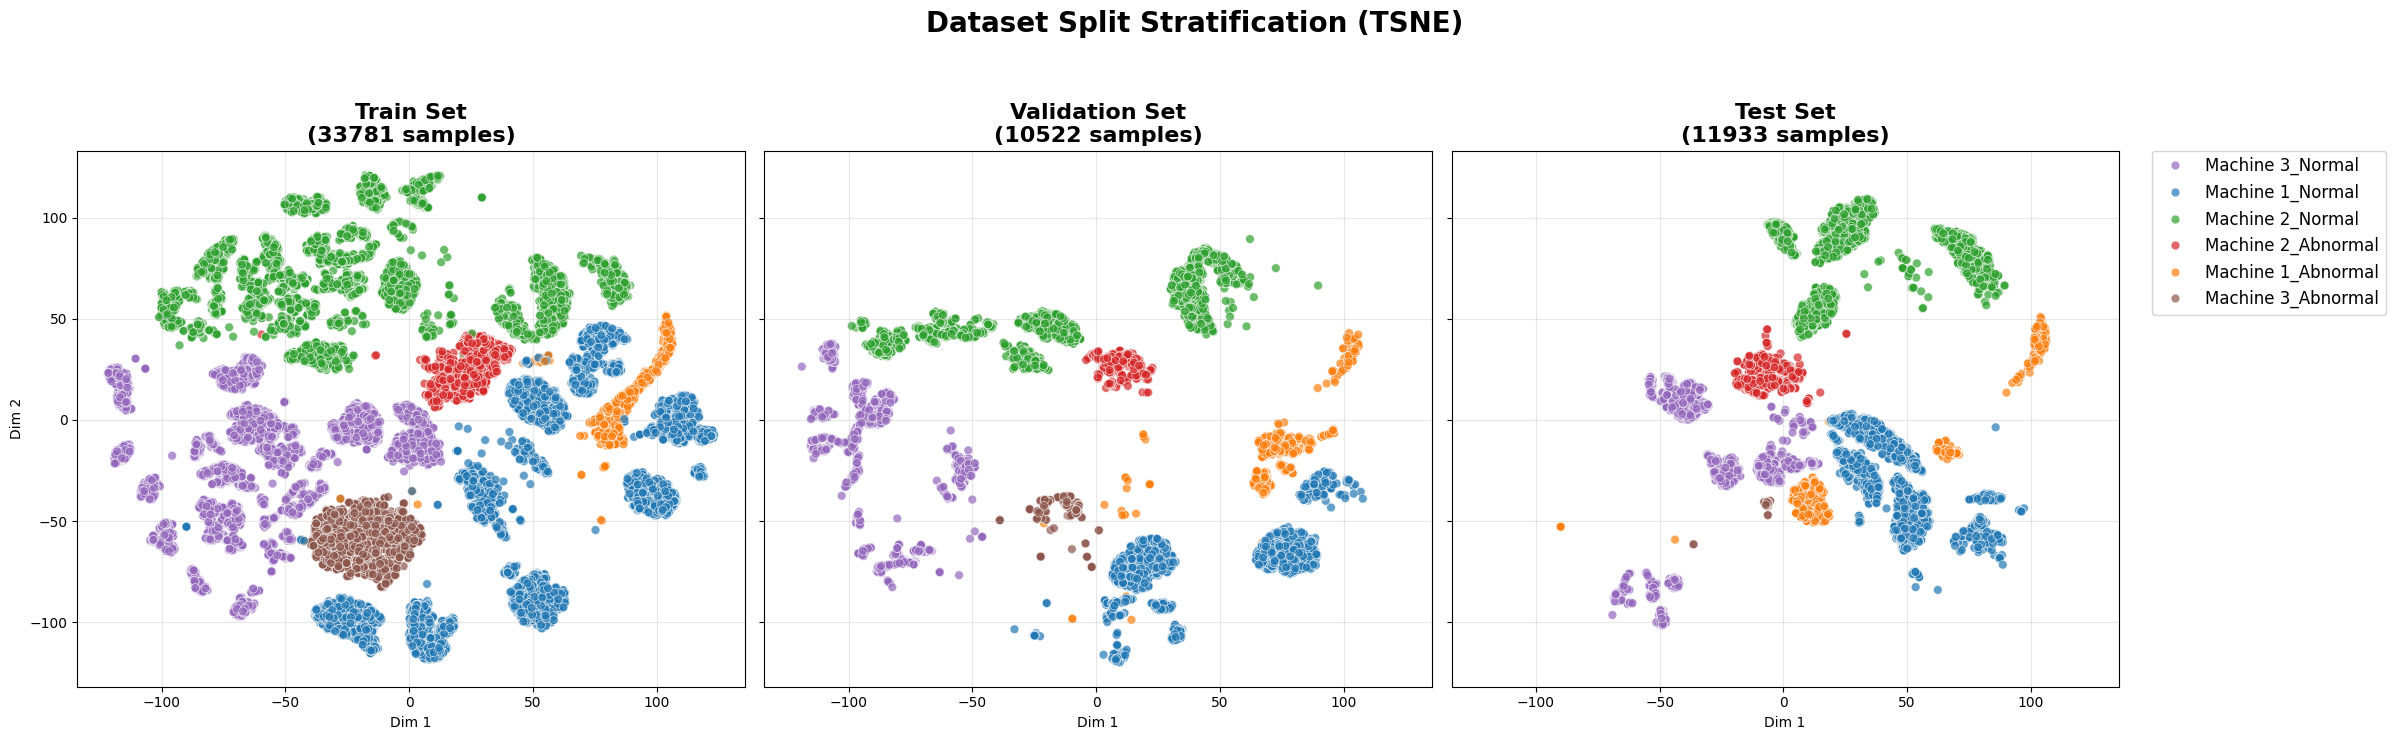

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize_data_splits(X_train, y_train, X_val, y_val, X_test, y_test, label_map, method='tsne'):
    """
    Combines splits to create a consistent 2D map, then plots them side-by-side.
    method: 'tsne' for deep cluster visualization, 'pca' for a quick structural look.
    """
    print(f"🌌 Generating consistent 2D projection using {method.upper()}...")
    
    # 1. Combine all data to ensure a shared spatial layout
    X_all = np.vstack((X_train, X_val, X_test))
    y_all = np.concatenate((y_train, y_val, y_test))
    
    # Keep track of which rows belong to which split
    n_train = len(X_train)
    n_val = len(X_val)
    n_test = len(X_test)
    
    split_labels = (
        ['Train'] * n_train + 
        ['Validation'] * n_val + 
        ['Test'] * n_test
    )
    
    # 2. Dimensionality Reduction
    if method.lower() == 'tsne':
        # Fast PCA first, then t-SNE
        n_comps = min(50, X_all.shape[1])
        X_pca = PCA(n_components=n_comps, random_state=42).fit_transform(X_all)
        X_2d = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42).fit_transform(X_pca)
    else:
        # Just pure PCA to 2D (Faster but less clustered)
        X_2d = PCA(n_components=2, random_state=42).fit_transform(X_all)
        
    # 3. Create a unified DataFrame for easy plotting with Seaborn
    # Reverse the label_map to get string names from integer IDs
    id_to_name = {v: k for k, v in label_map.items()}
    
    df = pd.DataFrame({
        'Dim 1': X_2d[:, 0],
        'Dim 2': X_2d[:, 1],
        'Class': [id_to_name[y] for y in y_all],
        'Split': split_labels
    })
    
    # Ensure consistent colors for classes across all plots
    class_names = list(label_map.keys())
    palette = dict(zip(class_names, sns.color_palette("tab10", len(class_names))))
    
    # 4. Plotting
    fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharex=True, sharey=True)
    splits = ['Train', 'Validation', 'Test']
    
    for i, split_name in enumerate(splits):
        ax = axes[i]
        subset = df[df['Split'] == split_name]
        
        sns.scatterplot(
            data=subset, 
            x='Dim 1', y='Dim 2', 
            hue='Class', 
            palette=palette,
            ax=ax, 
            alpha=0.7, 
            s=40,
            legend=(i == 2) # Only show legend on the last plot
        )
        
        ax.set_title(f"{split_name} Set\n({len(subset)} samples)", fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
    # Format the shared legend
    axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=12)
    plt.suptitle(f"Dataset Split Stratification ({method.upper()})", fontsize=20, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    plt.show()

# =====================================================================
# 🚀 HOW TO CALL THE FUNCTION (Run this cell after loading your data)
# =====================================================================
visualize_data_splits(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    label_map=LABEL_MAP, 
    method='tsne'  # Change to 'pca' if you want it to render instantly
)

In [11]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics.pairwise import cosine_distances
# from scipy.cluster.hierarchy import linkage, dendrogram

# print("🔬 Running 256D Diagnostics: Heatmap, Overlap Test, and Dendrogram...")

# # =====================================================================
# # 🎯 Select a specific class and its best labels from your previous run to test
# # =====================================================================
# # Change this to whatever class you want to diagnose
# TEST_CLASS_NAME = class_name
# class_id_to_test = LABEL_MAP[TEST_CLASS_NAME]

# # Isolate the raw 256D data and the labels generated by your GMM/K-Means run
# mask = (y_full == class_id_to_test)
# X_test_256d = embeddings[mask]

# # Assuming you saved the best labels from the previous cell in a dictionary
# # If you didn't save them, just re-run the predict step here:
# # e.g., labels_256d = gmm.predict(X_pca) 
# # For this example, replace `your_saved_labels` with the actual labels array
# labels_256d = best_labels  # <--- MAKE SURE THIS MATCHES THE CURRENT CLASS LABELS

# unique_clusters = np.unique(labels_256d)
# num_clusters = len(unique_clusters)

# fig = plt.figure(figsize=(24, 8))

# # ---------------------------------------------------------
# # Method 1: Pairwise Centroid Distance Heatmap (Cosine)
# # ---------------------------------------------------------
# ax1 = plt.subplot(1, 3, 1)

# # Calculate 256D centroids
# centroids_256d = np.array([X_test_256d[labels_256d == c].mean(axis=0) for c in unique_clusters])

# # Calculate Cosine Distances (0 = identical, 1 = orthogonal, 2 = opposite)
# dist_matrix = cosine_distances(centroids_256d)

# sns.heatmap(dist_matrix, annot=True, cmap='viridis_r', fmt=".2f", ax=ax1, 
#             xticklabels=unique_clusters, yticklabels=unique_clusters)
# ax1.set_title("1. Centroid Cosine Distance (256D)\n(Dark/0.0 = Overlapping Clusters)", fontweight='bold')
# ax1.set_xlabel("Cluster ID")
# ax1.set_ylabel("Cluster ID")

# # ---------------------------------------------------------
# # Method 2: Intra-cluster vs Inter-cluster Overlap Test
# # ---------------------------------------------------------
# ax2 = plt.subplot(1, 3, 2)

# intra_dists = []
# inter_dists = []

# for i, point in enumerate(X_test_256d):
#     my_cluster = labels_256d[i]
#     point_reshaped = point.reshape(1, -1)
    
#     # Distance to own centroid (Intra)
#     my_centroid = centroids_256d[np.where(unique_clusters == my_cluster)[0][0]].reshape(1, -1)
#     intra_dist = cosine_distances(point_reshaped, my_centroid)[0][0]
#     intra_dists.append(intra_dist)
    
#     # Distance to nearest OTHER centroid (Inter)
#     other_centroids = centroids_256d[unique_clusters != my_cluster]
#     if len(other_centroids) > 0:
#         dists_to_others = cosine_distances(point_reshaped, other_centroids)
#         inter_dists.append(np.min(dists_to_others))

# sns.kdeplot(intra_dists, fill=True, label='Intra-cluster (Distance to own center)', color='blue', ax=ax2)
# if len(inter_dists) > 0:
#     sns.kdeplot(inter_dists, fill=True, label='Inter-cluster (Distance to nearest neighbor)', color='orange', ax=ax2)

# ax2.set_title("2. Density Overlap Test (256D)\n(If distributions overlap heavily, clusters are fake)", fontweight='bold')
# ax2.set_xlabel("Cosine Distance")
# ax2.set_ylabel("Density")
# ax2.legend()

# # ---------------------------------------------------------
# # Method 3: Agglomerative Dendrogram (Bottom-Up)
# # ---------------------------------------------------------
# ax3 = plt.subplot(1, 3, 3)

# # We use 'average' linkage with 'cosine' distance for high-dimensional accuracy
# linked = linkage(X_test_256d, method='average', metric='cosine')

# dendrogram(linked, truncate_mode='lastp', p=30, ax=ax3, 
#            leaf_rotation=90, leaf_font_size=10, show_contracted=True)

# ax3.set_title("3. Hierarchical Dendrogram (256D)\n(Count the long vertical lines at the top)", fontweight='bold')
# ax3.set_xlabel("Sample Index / Cluster Size")
# ax3.set_ylabel("Cosine Distance")

# plt.tight_layout()
# plt.show()